In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


In [3]:
!pip install cartopy
!pip install netCDF4
!pip install pyrsimg


In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4 as nc
import numpy as np
from pyrsimg import readTiff, imgShow


In [5]:
## s3 data
path_s3l2 = 'data/radar/S3A_SR_2_LAN____20230824T030706_20230824T035734_20230919T063755_3028_102_289______PS1_O_NT_004.SEN3/enhanced_measurement.nc'
## remote sensing data
path_rsimg = 'data/rsimg/dianchi_s2_20200511_wgs84_resam50m.tif'
path_rsimg_wat = 'data/rsimg/dianchi_s2_20200511_wat_wgs84_resam50m.tif'


In [6]:
## 1. s3l2 altimetry data
s3l2 = nc.Dataset(path_s3l2)    ##
## 2. remote sensing image
rsimg = readTiff(path_rsimg)


In [7]:
print('number of variables: ', len(s3l2.variables.keys()))
list(s3l2.variables.keys())


number of variables:  376


['time_01',
 'time_20_ku',
 'time_20_c',
 'echo_sample_ind',
 'UTC_day_01',
 'UTC_sec_01',
 'UTC_day_20_ku',
 'UTC_sec_20_ku',
 'UTC_day_20_c',
 'UTC_sec_20_c',
 'UTC_time_1hz_20_ku',
 'UTC_time_1hz_20_c',
 'lat_01',
 'lon_01',
 'lat_20_ku',
 'lon_20_ku',
 'lat_20_c',
 'lon_20_c',
 'lat_cor_20_ku',
 'lon_cor_20_ku',
 'lat_cor_20_c',
 'lon_cor_20_c',
 'surf_type_01',
 'surf_type_20_ku',
 'surf_type_20_c',
 'surf_class_01',
 'surf_class_20_ku',
 'surf_class_20_c',
 'rad_surf_type_01',
 'angle_coast_01',
 'angle_coast_20_ku',
 'angle_coast_20_c',
 'dist_coast_01',
 'dist_coast_20_ku',
 'dist_coast_20_c',
 'alt_01',
 'alt_20_ku',
 'alt_20_c',
 'orb_alt_rate_01',
 'orb_alt_rate_20_ku',
 'orb_alt_rate_20_c',
 'tracker_range_20_ku',
 'tracker_range_20_c',
 'tracker_range_20_plrm_ku',
 'h0_nav_dem_20_ku',
 'agc_01_ku',
 'agc_01_c',
 'agc_01_plrm_ku',
 'agc_20_ku',
 'agc_20_c',
 'agc_20_plrm_ku',
 'agc_numval_01_ku',
 'agc_numval_01_c',
 'agc_numval_01_plrm_ku',
 'agc_rms_01_ku',
 'agc_rms_01_c

In [8]:
lat_20_ku = s3l2['lat_cor_20_ku'][:]
lon_20_ku = s3l2['lon_cor_20_ku'][:]
time_20_ku = s3l2['time_20_ku'][:]


Text(0.5, 1.0, 'sentinel-3 altimetry data')

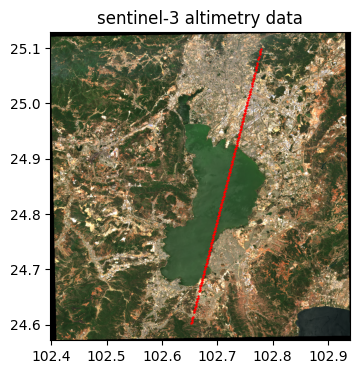

In [9]:
ids = np.where((lat_20_ku[:]>24.6) & (lat_20_ku[:]<25.1))
fig = plt.figure(figsize=(4, 4))
ax = plt.subplot(1,1,1)
imgShow(rsimg.array, extent=rsimg.geoextent, ax=ax)
plt.scatter(x=lon_20_ku[ids], y=lat_20_ku[ids], s=0.5, color='red')  ## altimetry data
plt.title('sentinel-3 altimetry data')


1. 地球物理改正：干对流层改正，湿对流层改正，电离层改正，负荷潮改正，固体地球改正，极潮改正。

In [24]:
geo_corr_01hz = ['mod_dry_tropo_cor_meas_altitude_01',
        'mod_wet_tropo_cor_meas_altitude_01',
        'iono_cor_gim_01_ku',
        'load_tide_sol1_01',
        'solid_earth_tide_01',
        'pole_tide_01']

cor_01hz = 0
for cor_01hz_name in geo_corr_01hz:
    cor_01hz += s3l2[cor_01hz_name][:]

print(cor_01hz.shape)
print(cor_01hz)


(2020,)
[-2.4047 -2.4053 -2.4055 ... -1.7423 -1.7477 -1.7549]


In [25]:
# s3l2['iono_cor_alt_01_ku']


In [26]:
# s3l2['iono_cor_gim_01_ku']


In [28]:
def hz01_hz20(data_01hz, time_01hz, time_20hz):
    time_20hz_ = np.expand_dims(time_20hz, axis=1)
    dif_time = abs(time_20hz_-time_01hz)
    ind_min = dif_time.argmin(axis=1)
    data_20hz=data_01hz[ind_min]
    return data_20hz


In [29]:
times_20 = s3l2['time_20_ku'][:]
times_01 = s3l2['time_01'][:]
cor_20hz = hz01_hz20(data_01hz=cor_01hz, \
        time_01hz=times_01, time_20hz=times_20)
print(cor_20hz.shape)


(40417,)


In [30]:
## 1. 没有地球物理改正的地面高
h_ocean = s3l2['alt_20_ku'][:] - s3l2['range_ocean_20_ku'][:]
h_ocean = h_ocean.filled(np.nan)

## 2. 地球物理改正的地面高,ocean
h_ocean_cor = s3l2['alt_20_ku'][:] - s3l2['range_ocean_20_ku'][:]-cor_20hz
h_ocean_cor = h_ocean_cor.filled(np.nan)

## 3. 地球物理改正的地面高,ocog
h_ocog_cor = s3l2['alt_20_ku'][:] - s3l2['range_ocog_20_ku'][:]-cor_20hz
h_ocog_cor = h_ocog_cor.filled(np.nan)



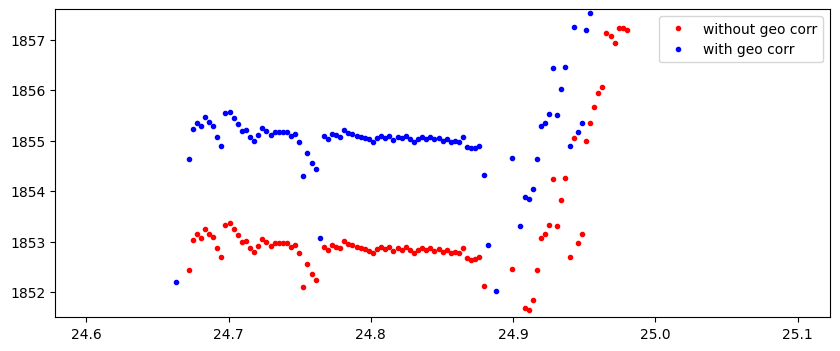

In [31]:
plt.figure(figsize=(10,4))
plt.plot(lat_20_ku[ids], h_ocean[ids], 'r.', label='without geo corr')
plt.plot(lat_20_ku[ids], h_ocean_cor[ids], 'b.', label='with geo corr')
plt.ylim([1851.5, 1857.6])
plt.legend()


(1854.5, 1855.6)

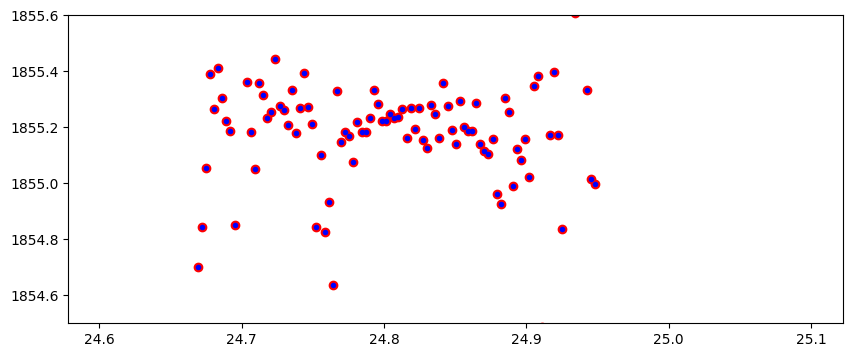

In [35]:
plt.figure(figsize=(10,4))
h_ocog_official = s3l2['elevation_ocog_20_ku'][:]
plt.plot(lat_20_ku[ids], h_ocog_official[ids], 'ro')
plt.plot(lat_20_ku[ids], h_ocog_cor[ids], 'b.')
plt.ylim(1854.5, 1855.6)


波形重跟踪处理

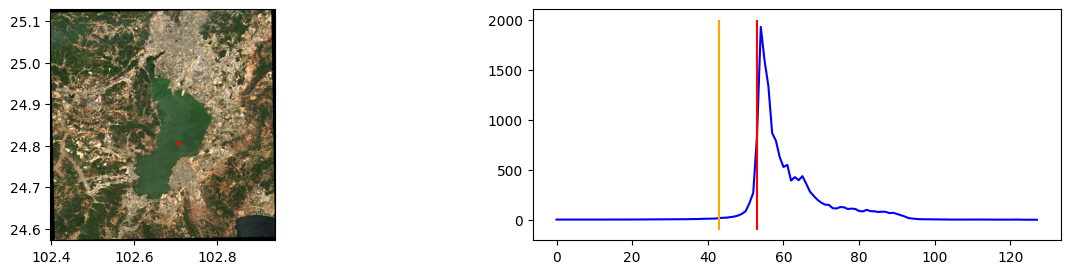

In [36]:
ids = np.where((lat_20_ku[:]>24.8) & (lat_20_ku[:]<24.81))[0]
id = ids[0]
id
wf_sar = s3l2['waveform_20_ku'][:][id]
wf_sar.shape
fig, ax = plt.subplots(1,2, figsize=(15,3))
imgShow(rsimg.array, extent=rsimg.geoextent, ax=ax[0])
ax[0].scatter(x=lon_20_ku[id], y=lat_20_ku[id], s=4, color='red')
ax[1].plot(s3l2['echo_sample_ind'][:], wf_sar, color='blue')
gate_nominal = 43
ax[1].vlines(gate_nominal, ymin=-100, ymax=2000, color='orange')
gate_retraker = 53
ax[1].vlines(gate_retraker, ymin=-100, ymax=2000, color='red')


In [37]:
print(s3l2['elevation_ocog_20_ku'][:][id])

h_cor = s3l2['alt_20_ku'][id]-s3l2['tracker_range_20_ku'][id]-cor_20hz[id]
print(h_cor)

cor_retracker = (53 - 43)*3.125 * 0.3/2

h_cor_retraker = s3l2['alt_20_ku'][id]-(s3l2['tracker_range_20_ku'][id] + cor_retracker)-cor_20hz[id]
print(h_cor_retraker)



1855.2349000000002
1860.6048999999364
1855.9173999999364
